<a href="https://www.kaggle.com/code/lalit7881/student-placement-prediction?scriptVersionId=301526105" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/suhanigupta04/student-placement-prediction-dataset/student_placement_synthetic.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/suhanigupta04/student-placement-prediction-dataset/student_placement_synthetic.csv")

In [3]:
df.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [5]:
df.describe()

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


In [6]:
df.isnull().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.dtypes

branch                        object
college_tier                  object
cgpa                         float64
backlogs                       int64
coding_skills                float64
dsa_score                    float64
aptitude_score               float64
communication_skills         float64
ml_knowledge                 float64
system_design                float64
internships                    int64
projects_count                 int64
certifications                 int64
hackathons                     int64
open_source_contributions      int64
extracurriculars               int64
placement_status               int64
salary_package_lpa           float64
dtype: object

In [9]:
df.shape

(100000, 18)

In [10]:
df.columns

Index(['branch', 'college_tier', 'cgpa', 'backlogs', 'coding_skills',
       'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge',
       'system_design', 'internships', 'projects_count', 'certifications',
       'hackathons', 'open_source_contributions', 'extracurriculars',
       'placement_status', 'salary_package_lpa'],
      dtype='object')

In [11]:
df.nunique()

branch                          7
college_tier                    3
cgpa                          597
backlogs                        4
coding_skills                  91
dsa_score                      91
aptitude_score                765
communication_skills           91
ml_knowledge                  101
system_design                 101
internships                     4
projects_count                  6
certifications                  5
hackathons                      4
open_source_contributions       3
extracurriculars                4
placement_status                2
salary_package_lpa           1654
dtype: int64

## Data visualizations

In [12]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

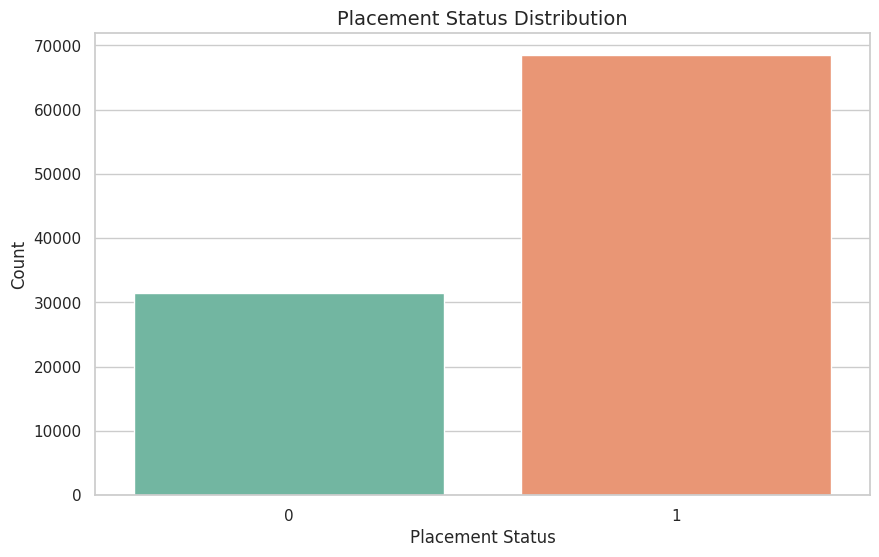

In [13]:
plt.figure()
sns.countplot(x="placement_status", data=df, palette="Set2")
plt.title("Placement Status Distribution", fontsize=14)
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.show()

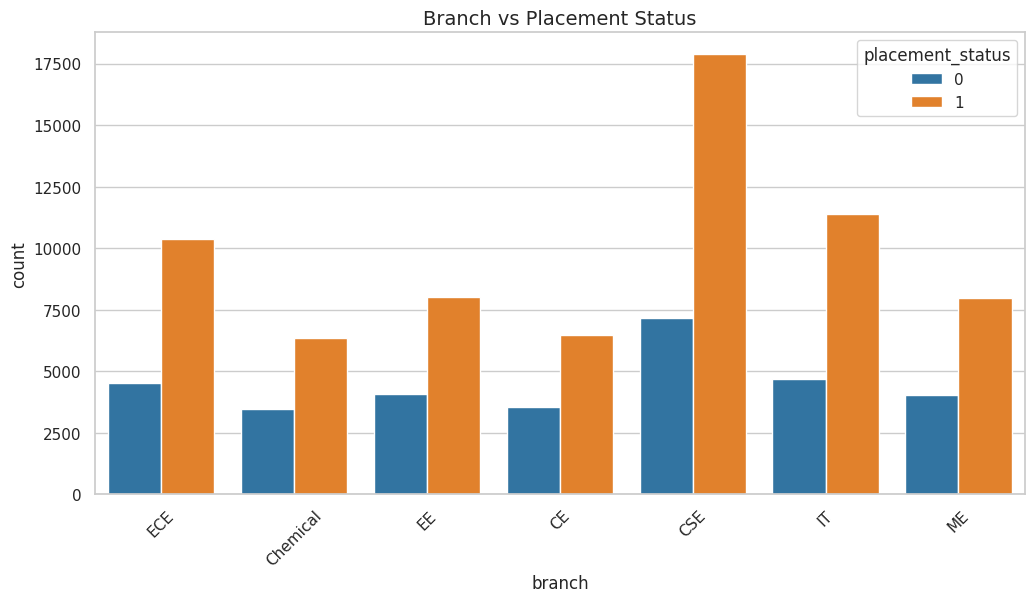

In [14]:
plt.figure(figsize=(12,6))
sns.countplot(x="branch", hue="placement_status", data=df, palette="tab10")
plt.title("Branch vs Placement Status", fontsize=14)
plt.xticks(rotation=45)
plt.show()

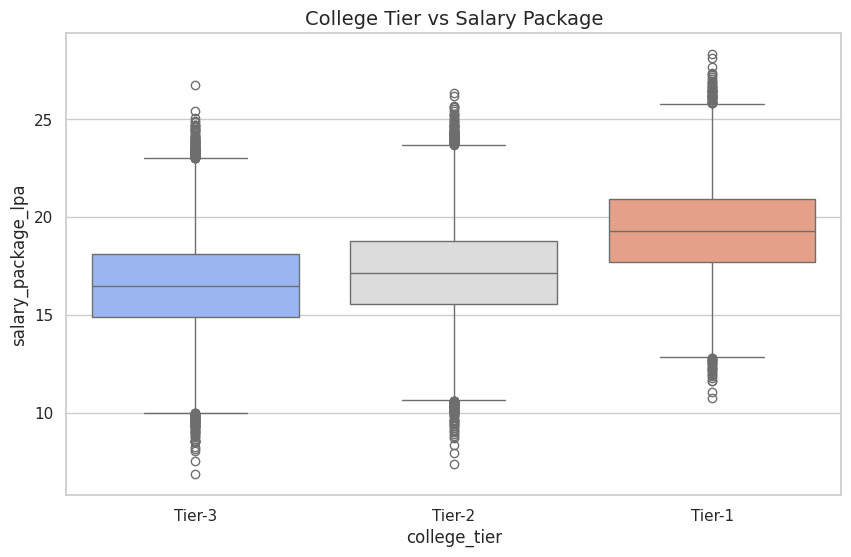

In [15]:
plt.figure()
sns.boxplot(x="college_tier", y="salary_package_lpa", data=df, palette="coolwarm")
plt.title("College Tier vs Salary Package", fontsize=14)
plt.show()

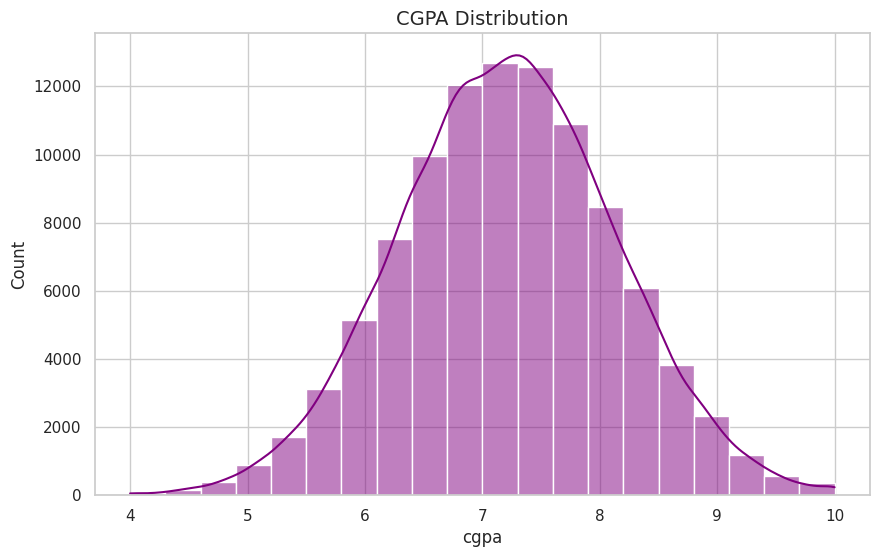

In [16]:
plt.figure()
sns.histplot(df["cgpa"], bins=20, kde=True, color="purple")
plt.title("CGPA Distribution", fontsize=14)
plt.show()

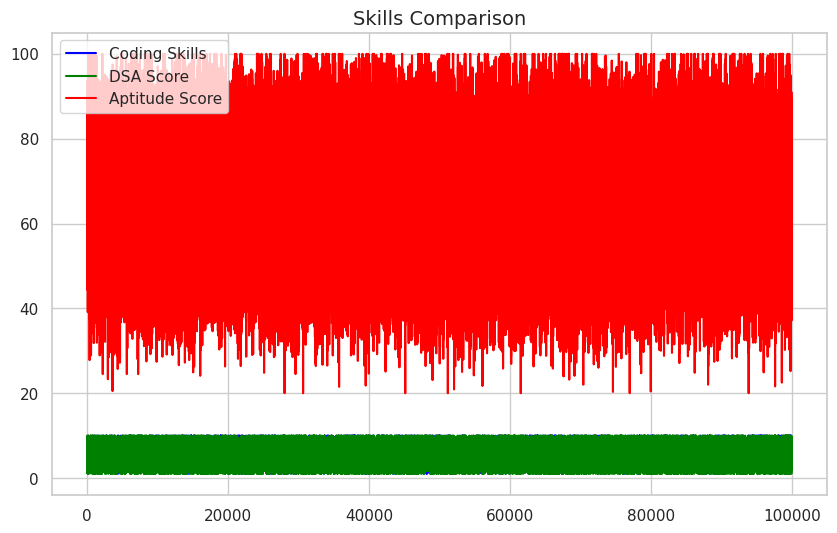

In [17]:
plt.figure()
plt.plot(df["coding_skills"], color="blue", label="Coding Skills")
plt.plot(df["dsa_score"], color="green", label="DSA Score")
plt.plot(df["aptitude_score"], color="red", label="Aptitude Score")
plt.legend()
plt.title("Skills Comparison", fontsize=14)
plt.show()

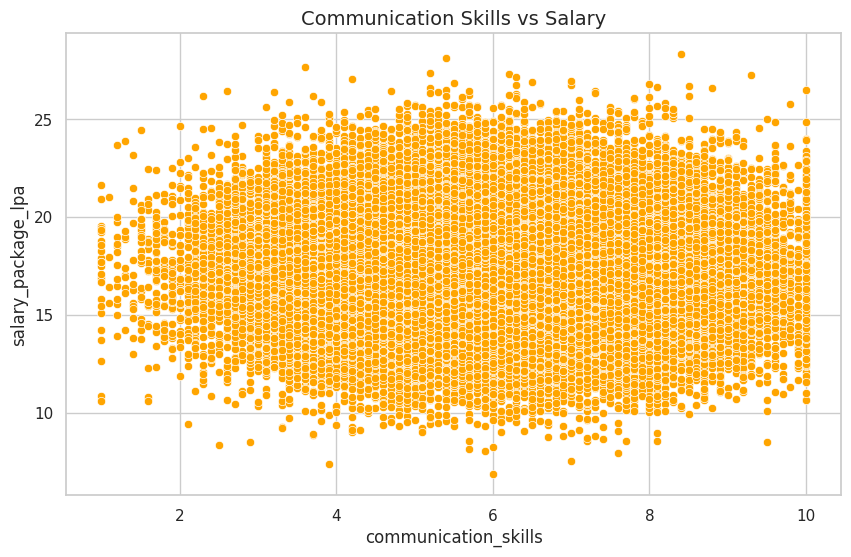

In [18]:
plt.figure()
sns.scatterplot(x="communication_skills", 
                y="salary_package_lpa", 
                data=df, 
                color="orange")
plt.title("Communication Skills vs Salary", fontsize=14)
plt.show()

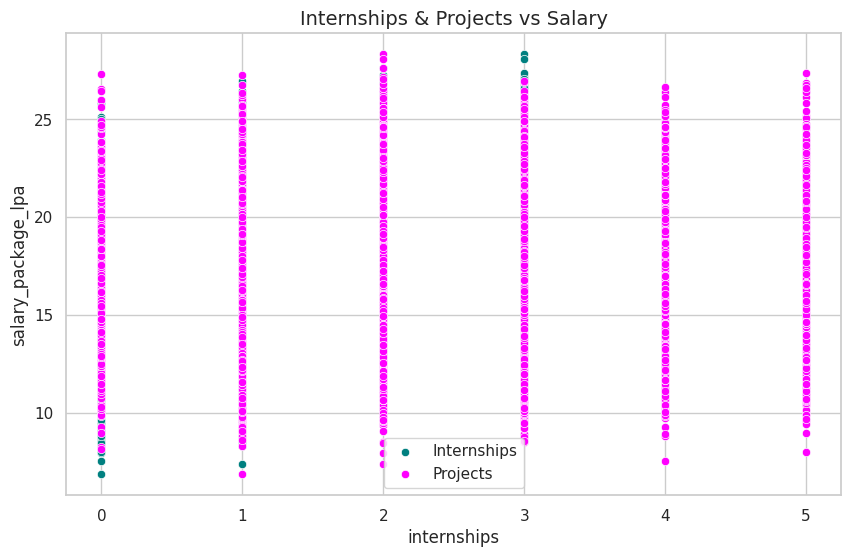

In [19]:
plt.figure()
sns.scatterplot(x="internships", 
                y="salary_package_lpa", 
                data=df, 
                color="teal", 
                label="Internships")

sns.scatterplot(x="projects_count", 
                y="salary_package_lpa", 
                data=df, 
                color="magenta", 
                label="Projects")

plt.legend()
plt.title("Internships & Projects vs Salary", fontsize=14)
plt.show()

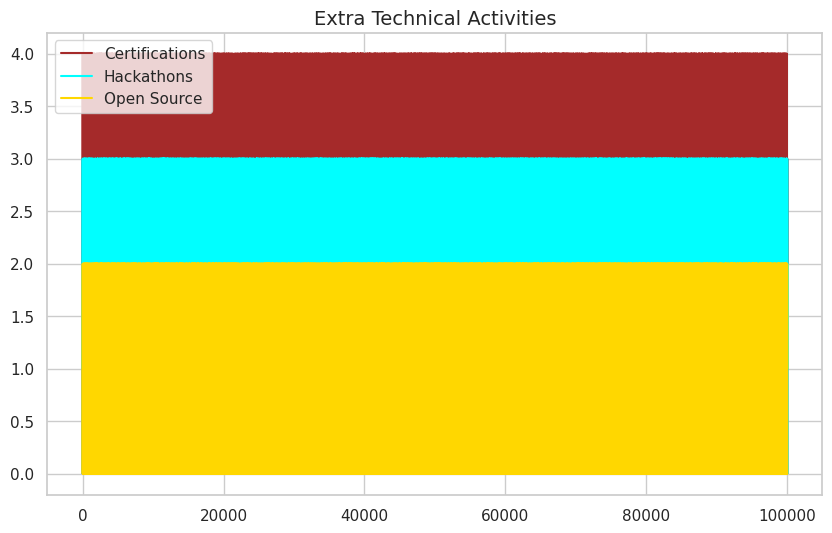

In [20]:
plt.figure()
plt.plot(df["certifications"], color="brown", label="Certifications")
plt.plot(df["hackathons"], color="cyan", label="Hackathons")
plt.plot(df["open_source_contributions"], color="gold", label="Open Source")
plt.legend()
plt.title("Extra Technical Activities", fontsize=14)
plt.show()

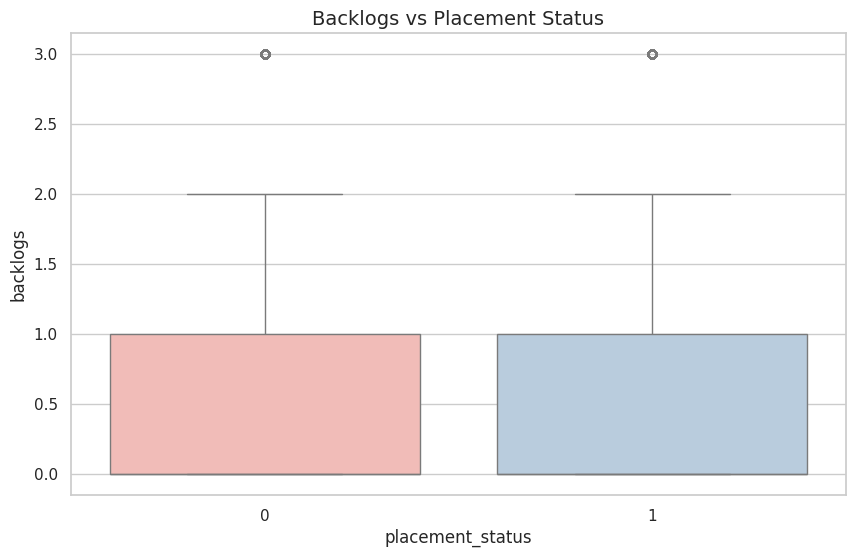

In [21]:
plt.figure()
sns.boxplot(x="placement_status", 
            y="backlogs", 
            data=df, 
            palette="Pastel1")
plt.title("Backlogs vs Placement Status", fontsize=14)
plt.show()

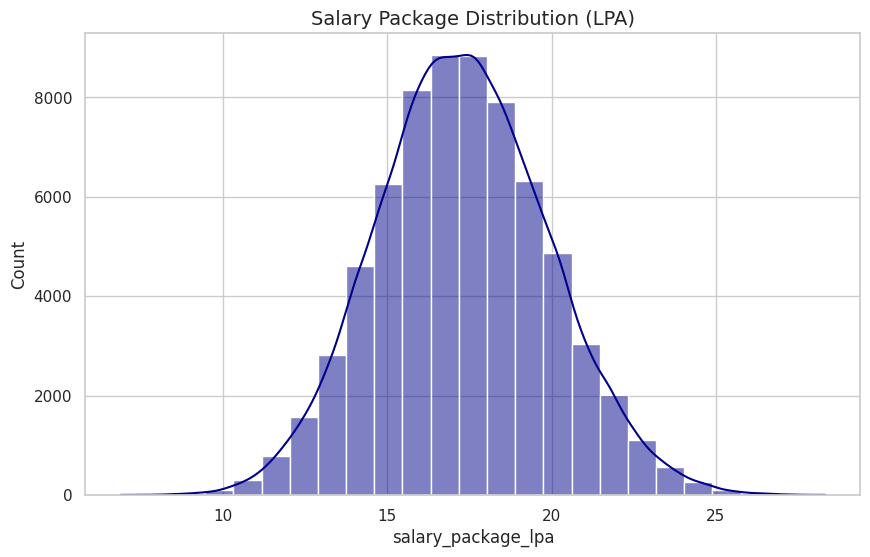

In [22]:
plt.figure()
sns.histplot(df["salary_package_lpa"], 
             bins=25, 
             kde=True, 
             color="darkblue")
plt.title("Salary Package Distribution (LPA)", fontsize=14)
plt.show()

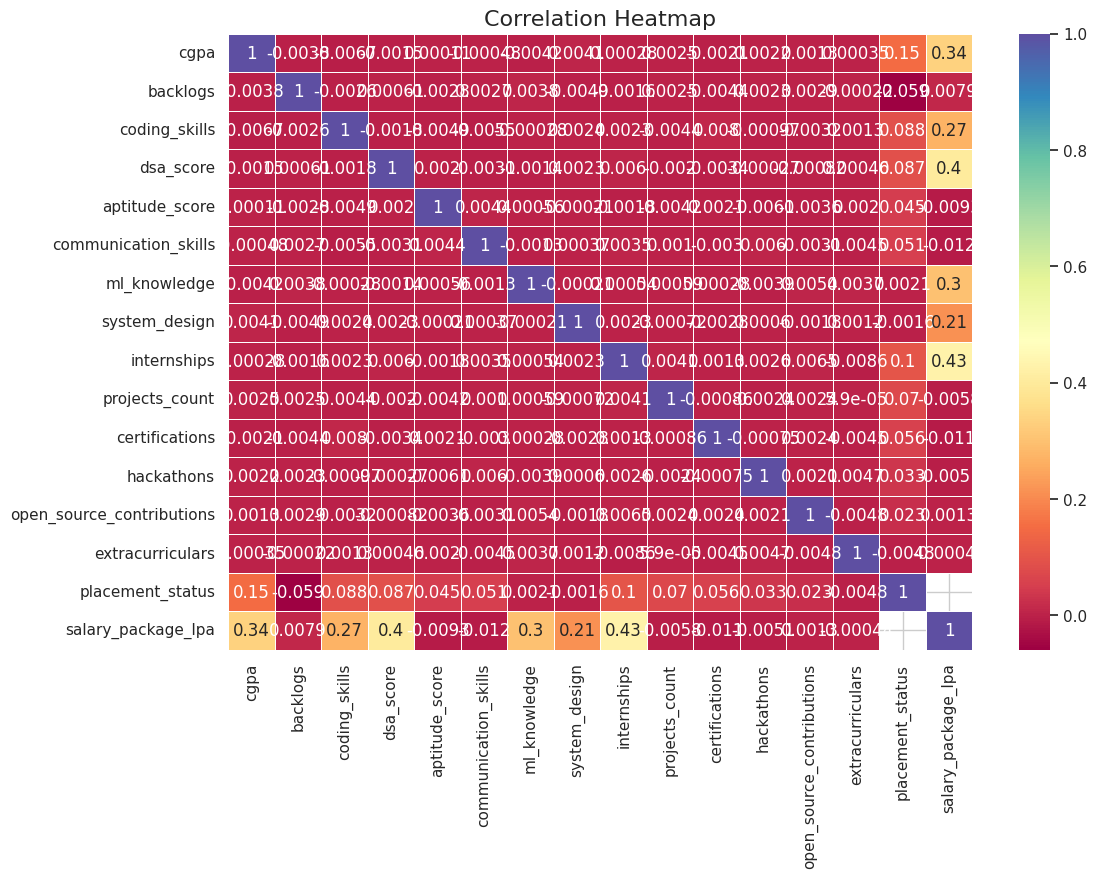

In [23]:
plt.figure(figsize=(12,8))

numeric_cols = df.select_dtypes(include=np.number)

sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap="Spectral",
            linewidths=0.5)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

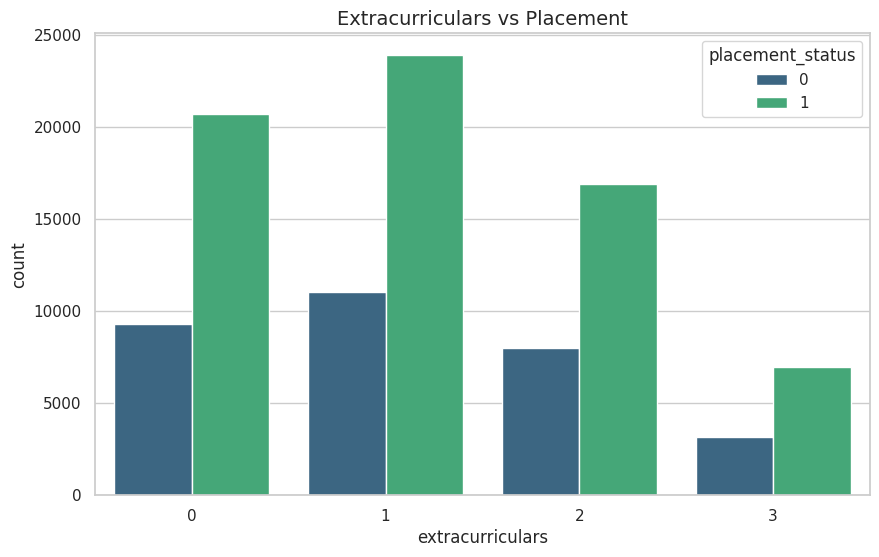

In [24]:
plt.figure()
sns.countplot(x="extracurriculars", 
              hue="placement_status", 
              data=df, 
              palette="viridis")
plt.title("Extracurriculars vs Placement", fontsize=14)
plt.show()

## Feature engineering

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [26]:
df = df.copy()

# Encode categorical columns
le = LabelEncoder()

categorical_cols = ["branch", "college_tier", "placement_status"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Define Features and Target
X = df.drop(["placement_status", "salary_package_lpa"], axis=1)
y = df["placement_status"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}


MODEL: Logistic Regression
Accuracy: 69.78%


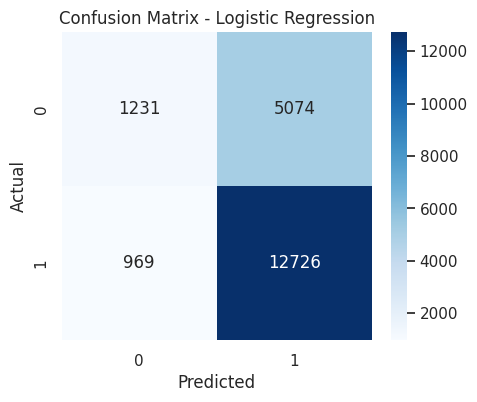

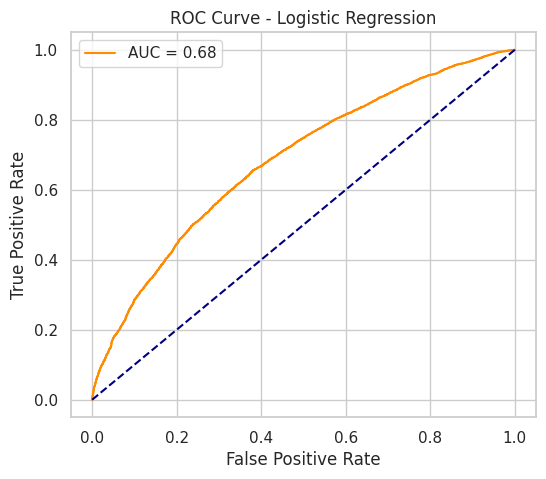


MODEL: Decision Tree
Accuracy: 59.90%


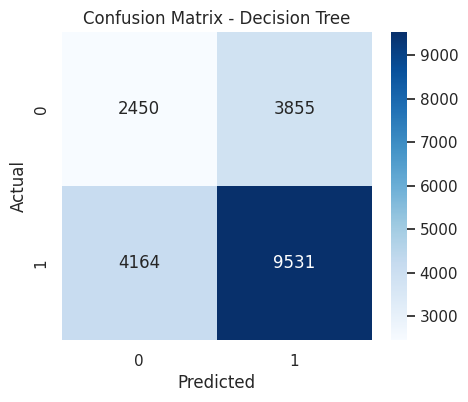

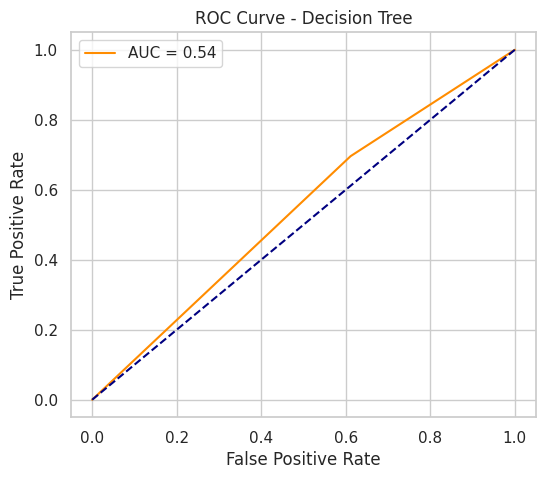


MODEL: Random Forest
Accuracy: 68.91%


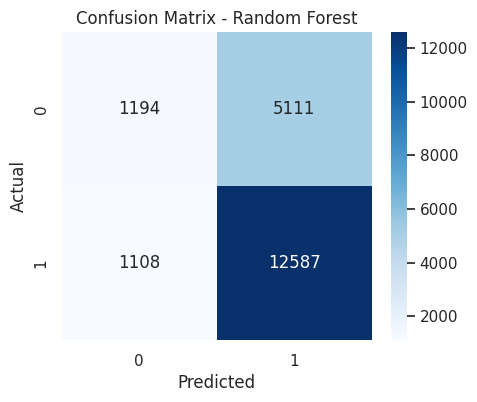

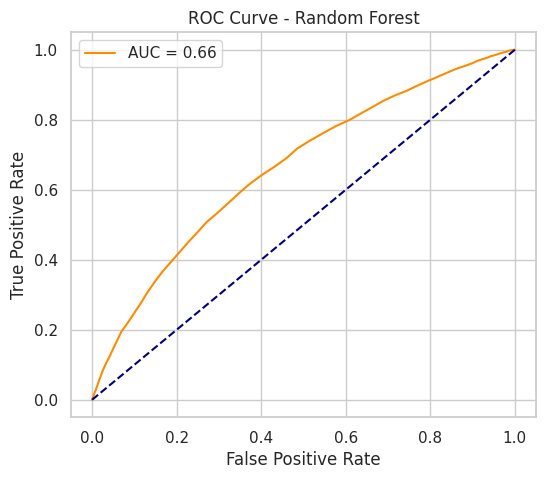


MODEL: KNN
Accuracy: 64.50%


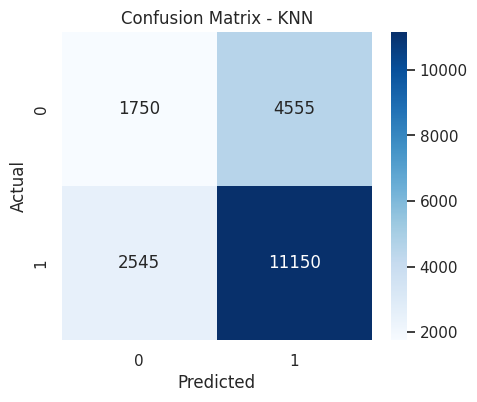

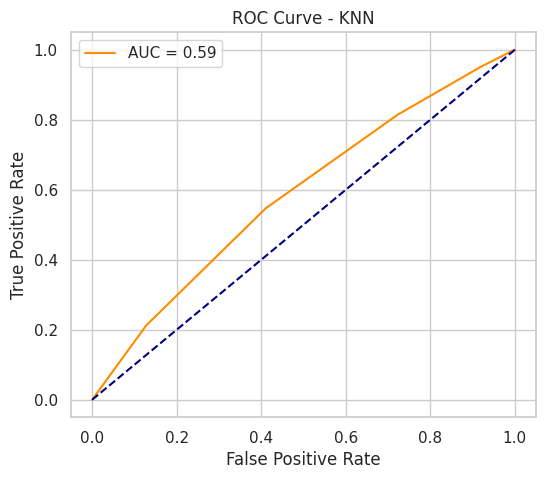


MODEL: Naive Bayes
Accuracy: 69.56%


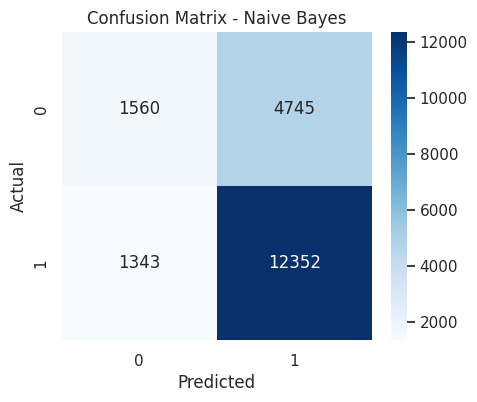

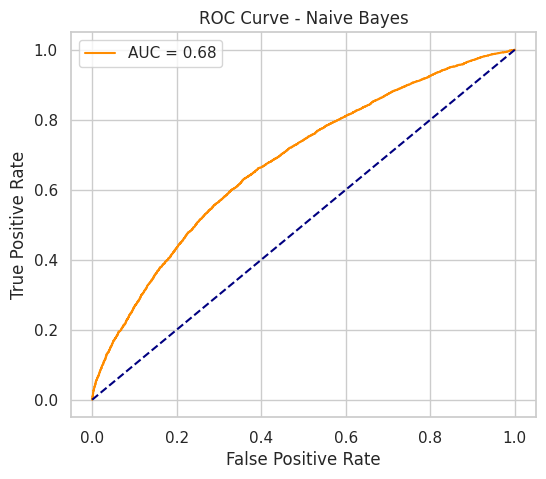

In [30]:
for name, model in models.items():
    
    print("\n" + "="*60)
    print(f"MODEL: {name}")
    print("="*60)
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred) * 100
    print(f"Accuracy: {acc:.2f}%")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ROC Curve
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        continue   # Skip ROC if probability not available
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="darkorange")
    plt.plot([0,1], [0,1], linestyle="--", color="navy")
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

## Thank you..pls upvote!!!